<a href="https://colab.research.google.com/github/M-Abbi/Probability-Statistics-Bootcamp/blob/main/Gamma_Distribution_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The Problem: FX Desk Liquidity Risk

An FX desk takes on a massive **\$200 million toxic inventory block** of an exotic currency pair. Due to market impact, they cannot dump this all at once. They must wait for **5 distinct institutional "matching" buy orders** ($\alpha = 5$) to safely absorb the inventory.

* These institutional buyers arrive randomly at an average rate of $\lambda = 0.4$ orders per hour (meaning on average, 1 order every 2.5 hours).
* The desk is exposed to extreme overnight volatility. Management mandates a strict rule: **If the inventory is not cleared within 12 hours ($t = 12$), the desk faces a severe risk penalty.**

The Quant needs to calculate:

1. **$P(T \le 12)$**: The probability that the desk successfully clears the risk *before* the 12-hour limit using the Gamma Cumulative Distribution Function (CDF):

$$F(t; \alpha, \lambda) = \int_{0}^{t} \frac{\lambda^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\lambda x} dx$$

2. **Conditional Expected Loss**: If they *fail* to clear it by hour 12 ($T > 12$), what is the probability density of how much longer they will be stuck holding the bag? This requires calculating the conditional survival probability:

$$P(T > t_{\text{future}} \mid T > 12) = \frac{P(T > t_{\text{future}})}{P(T > 12)}$$

In [2]:
import numpy as np
import scipy.stats as stats

# --- DESK PARAMETERS ---
alpha = 5          # Number of matching institutional orders required to clear inventory
lambda_rate = 0.4  # Average arrival rate of orders per hour
time_limit = 12    # Management's strict risk threshold (hours)

# In scipy, the Gamma distribution uses 'shape' (alpha) and 'scale' (theta)
# Note: scale (theta) = 1 / lambda
shape_param = alpha
scale_param = 1 / lambda_rate

# --- 1. PROBABILITY CALCULATIONS ---

# Expected (average) time to clear the position
expected_time = shape_param * scale_param

# Calculate the probability of clearing BEFORE the 12-hour risk limit (Gamma CDF)
prob_cleared_in_time = stats.gamma.cdf(time_limit, a=shape_param, scale=scale_param)

# Calculate the probability of breaching the risk limit (Survival Function: 1 - CDF)
prob_risk_breach = stats.gamma.sf(time_limit, a=shape_param, scale=scale_param)

print("=" * 50)
print("       FX DESK INVENTORY RISK REPORT             ")
print("=" * 50)
print(f"Required Counterparty Orders (Alpha) : {alpha}")
print(f"Expected Wait Time to Clear         : {expected_time:.2f} hours")
print(f"Probability of Clearing within 12h  : {prob_cleared_in_time * 100:.2f}%")
print(f"Probability of Risk Breach (> 12h)   : {prob_risk_breach * 100:.2f}%")
print("-" * 50)

# --- 2. CONDITIONAL RISK PRICING ---
# If we breach the 12-hour mark, what is the probability we are stuck for over 18 hours total?
# Mathematically: P(T > 18 | T > 12) = P(T > 18) / P(T > 12)

prob_over_18h = stats.gamma.sf(18, a=shape_param, scale=scale_param)
conditional_fail_prob = prob_over_18h / prob_risk_breach

print(f"IF 12 hours pass without clearing:")
print(f" -> Prob of being stuck until hour 18: {conditional_fail_prob * 100:.2f}%")
print("=" * 50)

       FX DESK INVENTORY RISK REPORT             
Required Counterparty Orders (Alpha) : 5
Expected Wait Time to Clear         : 12.50 hours
Probability of Clearing within 12h  : 52.37%
Probability of Risk Breach (> 12h)   : 47.63%
--------------------------------------------------
IF 12 hours pass without clearing:
 -> Prob of being stuck until hour 18: 32.65%


# Visualizing the Risk Horizon
To help the Head of Trading understand the desk's exposure, quants typically plot the Probability Density Function (PDF) and highlight the "Danger Zone."

<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_20490/555174261.py:20: SyntaxWarning: invalid escape sequence '\$'
  plt.title('FX Desk: Waiting Time Distribution to Clear \$200M Position')


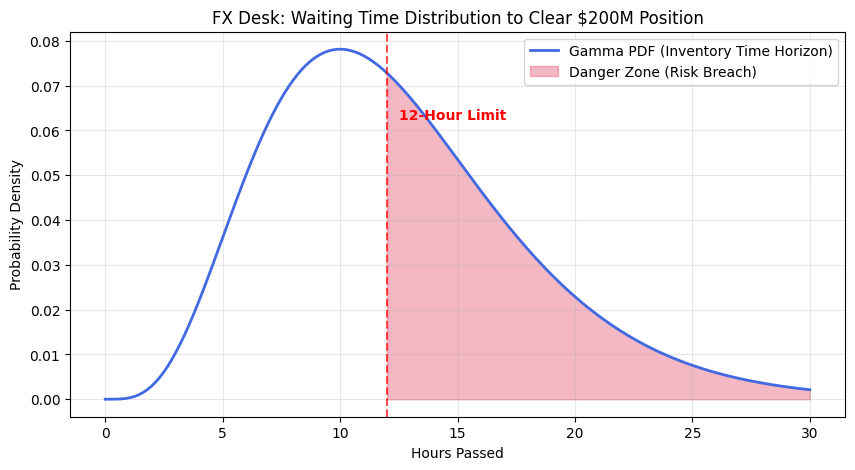

In [3]:
import matplotlib.pyplot as plt

# Generate time steps for plotting (0 to 30 hours)
t_space = np.linspace(0, 30, 500)
pdf_values = stats.gamma.pdf(t_space, a=shape_param, scale=scale_param)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_space, pdf_values, label='Gamma PDF (Inventory Time Horizon)', color='royalblue', lw=2)

# Highlight the Danger Zone (t > 12 hours)
danger_t = np.linspace(time_limit, 30, 200)
danger_pdf = stats.gamma.pdf(danger_t, a=shape_param, scale=scale_param)
plt.fill_between(danger_t, danger_pdf, color='crimson', alpha=0.3, label='Danger Zone (Risk Breach)')

# Vertical line at the 12-hour mark
plt.axvline(x=time_limit, color='red', linestyle='--', alpha=0.7)
plt.text(time_limit + 0.5, max(pdf_values)*0.8, '12-Hour Limit', color='red', fontweight='bold')

plt.title('FX Desk: Waiting Time Distribution to Clear \$200M Position')
plt.xlabel('Hours Passed')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()